In [18]:
# ============================================
# Install packages
# ============================================

!pip install torch torchvision tqdm matplotlib scikit-learn

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.transforms.functional import rotate

from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [20]:
vae_dataset = MNIST(
    "./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

vae_loader = DataLoader(vae_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

print("dataset size:", len(vae_dataset))

dataset size: 60000


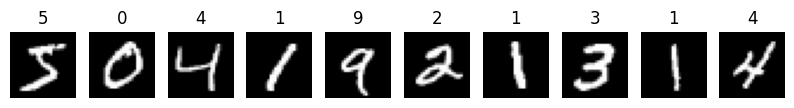

In [21]:
def show_digits():

    fig,ax = plt.subplots(1,10,figsize=(10,2))

    for i in range(10):

        img,label = vae_dataset[i]

        ax[i].imshow(img.squeeze(), cmap="gray")
        ax[i].set_title(label)
        ax[i].axis("off")

    plt.show()

show_digits()

In [22]:
class MNIST12(Dataset):

    def __init__(self, train=True):

        base = MNIST(
            "./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )

        self.images = []
        self.labels = []

        for img,label in base:

            if label in [1,2]:

                self.images.append(img)
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):

        return self.images[idx], self.labels[idx]

In [23]:
vae12_dataset = MNIST12(train=True)

vae12_loader = DataLoader(
    vae12_dataset,
    batch_size=128,
    shuffle=True, num_workers=2, pin_memory=True
)

print("dataset size:", len(vae12_dataset))

dataset size: 12700


In [24]:
test12_dataset = MNIST12(train=False)

test12_loader = DataLoader(
    test12_dataset,
    batch_size=128,
    shuffle=False, num_workers=2, pin_memory=True
)

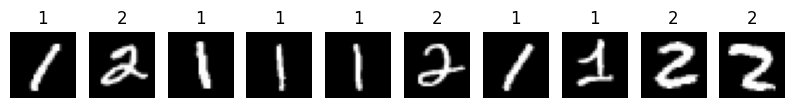

In [25]:
def show_digits_12():

    fig,ax = plt.subplots(1,10,figsize=(10,2))

    for i in range(10):

        img,label = vae12_dataset[i]

        ax[i].imshow(img.squeeze(), cmap="gray")
        ax[i].set_title(label)
        ax[i].axis("off")

    plt.show()

show_digits_12()

In [26]:
class RotatedMNIST(Dataset):

    def __init__(self, train=True):

        base = MNIST(
            "./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )

        self.images=[]
        self.labels=[]
        self.angles=[]

        for img,label in base:

            if label in [6,9]:
                rotations=[330,0,30]
            else:
                rotations=list(range(0,360,60))

            for r in rotations:

                self.images.append(rotate(img,r))
                self.labels.append(label)
                self.angles.append(r)

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        return self.images[idx],self.labels[idx],self.angles[idx]

In [27]:
rot_dataset = RotatedMNIST()
rot_loader = DataLoader(rot_dataset,batch_size=128,shuffle=True, num_workers=2, pin_memory=True)

print("dataset size:",len(rot_dataset))

dataset size: 324399


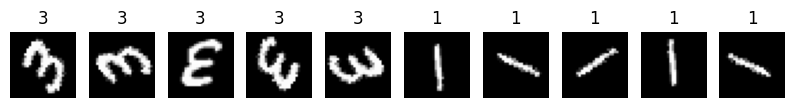

In [28]:
def show_digits_rot():

    fig, ax = plt.subplots(1,10,figsize=(10,2))

    for j,i in enumerate(range(40,50)):

        img,label,angle = rot_dataset[i]

        ax[j].imshow(img.squeeze(), cmap="gray")
        ax[j].set_title(label)
        ax[j].axis("off")

    plt.show()

show_digits_rot()

In [29]:
class RotatedMNIST12(Dataset):

    def __init__(self, base_dataset):

        self.images = []
        self.labels = []
        self.angles = []

        rotations = list(range(0,360,30))

        for img,label in base_dataset:

            if label in [6,9]:
                rotations = [330,0,30]
            else:
                rotations = list(range(0,360,30))

            for r in rotations:

                rot = rotate(img, r)

                self.images.append(rot)
                self.labels.append(label)
                self.angles.append(r)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx], self.angles[idx]

In [30]:
rot12_dataset = RotatedMNIST12(vae12_dataset)

rot12_loader = DataLoader(rot12_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

print("Rotated dataset size:", len(rot12_dataset))

Rotated dataset size: 152400


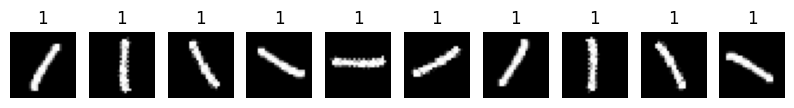

In [31]:
def show_digits_rot12():

    fig,ax = plt.subplots(1,10,figsize=(10,2))

    for i in range(10):

        img,label,angle = rot12_dataset[i]

        ax[i].imshow(img.squeeze(), cmap="gray")
        ax[i].set_title(label)
        ax[i].axis("off")

    plt.show()

show_digits_rot12()

In [32]:
LATENT_DIM = 8
BETA = 2

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),
            nn.ReLU(),

            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,3,2,1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*4*4, LATENT_DIM)
        self.fc_logvar = nn.Linear(128*4*4, LATENT_DIM)

    def forward(self,x):

        h = self.conv(x)
        h = h.view(h.size(0),-1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu,logvar


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(LATENT_DIM,128*4*4)

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,4,2,1),
            nn.Sigmoid()
        )

    def forward(self,z):

        h = self.fc(z)
        h = h.view(-1,128,4,4)

        x = self.deconv(h)

        return x[:,:,:28,:28]


class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self,x):

        mu,logvar = self.encoder(x)

        z = self.reparameterize(mu,logvar)

        recon = self.decoder(z)

        return recon,mu,logvar,z

In [34]:
# ============================================
# Efficient VAE training with kl_weight schedule
# ============================================
vae = VAE().to(device)

EPOCHS = 30
lambda_consistency = 0.3
lambda_contrastive = 0.2
num_pairs_per_label = 5  # sampled pairs per label per batch

optimizer = torch.optim.Adam(vae.parameters(), lr=2e-4)

for epoch in range(EPOCHS):
    vae.train()
    total_loss = 0

    kl_weight = min(1, epoch / 20)

    for x, label, angle in tqdm(rot_loader):

        # ======================================
        # FIX 1: move EVERYTHING to same device
        # ======================================
        x = x.to(device)
        label = label.to(device)
        angle = angle.to(device)   # ✅ IMPORTANT FIX

        # --------------------------
        # Forward pass
        # --------------------------
        recon, mu, logvar, z = vae(x)

        # Reconstruction loss
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)

        # KL divergence
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        consistency_loss = torch.tensor(0.0, device=device)
        contrastive_loss = torch.tensor(0.0, device=device)
        circle_loss = torch.tensor(0.0, device=device)

        labels_unique = label.unique()

        for lbl in labels_unique:

            mask = (label == lbl)

            ROT_DIM = 2
            CONTENT_DIM = LATENT_DIM - ROT_DIM

            mu_label = mu[mask]

            mu_content = mu_label[:, :CONTENT_DIM]
            mu_rot = mu_label[:, CONTENT_DIM:]

            N_lbl = mu_label.size(0)

            if N_lbl <= 1:
                continue

            # --------------------------
            # Random pairs
            # --------------------------
            idx1 = torch.randint(0, N_lbl, (num_pairs_per_label,), device=device)
            idx2 = torch.randint(0, N_lbl, (num_pairs_per_label,), device=device)

            same_idx = idx1 == idx2
            idx2[same_idx] = (idx2[same_idx] + 1) % N_lbl

            mu_i = mu_label[idx1]
            mu_j = mu_label[idx2]

            mu_rot_i = mu_rot[idx1]
            mu_rot_j = mu_rot[idx2]

            # --------------------------
            # Consistency loss
            # --------------------------
            consistency_loss += ((mu_rot_i - mu_rot_j)**2).mean()

            # --------------------------
            # Contrastive loss
            # --------------------------
            dist = torch.norm(mu_i - mu_j, dim=1)
            contrastive_loss += (dist ** 2).mean()

            # ======================================
            # Circle constraint (unit circle)
            # ======================================
            rot_norms = torch.norm(mu_rot, dim=1)
            circle_loss += ((rot_norms - 1.0)**2).mean()

            # ======================================
            # 🔥 FIX 2: SIN/COS ANGLE SUPERVISION
            # ======================================

            # Normalize predicted rotation vector
            mu_rot_norm = mu_rot / (mu_rot.norm(dim=1, keepdim=True) + 1e-8)

            pred_sin = mu_rot_norm[:, 1]
            pred_cos = mu_rot_norm[:, 0]

            # Ground truth angle
            angle_rad = angle[mask].float() * torch.pi / 180.0

            gt_sin = torch.sin(angle_rad)
            gt_cos = torch.cos(angle_rad)

            angle_loss = (
                F.mse_loss(pred_sin, gt_sin) +
                F.mse_loss(pred_cos, gt_cos)
            )

            circle_loss += angle_loss

        num_labels = len(labels_unique)

        if num_labels > 0:
            consistency_loss /= num_labels
            contrastive_loss /= num_labels
            circle_loss /= num_labels

        # --------------------------
        # Total loss
        # --------------------------
        loss = (
            recon_loss
            + BETA * kl_weight * kl
            + lambda_consistency * consistency_loss
            + 0.5 * circle_loss
            + lambda_contrastive * contrastive_loss
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch}: avg_loss={total_loss/len(rot_loader):.4f}, "
        f"recon={recon_loss.item():.4f}, kl={kl.item():.4f}, "
        f"consistency={consistency_loss.item():.4f}, "
        f"contrast={contrastive_loss.item():.4f}"
    )

  0%|          | 4/2535 [00:00<03:51, 10.93it/s]

100%|██████████| 2535/2535 [01:18<00:00, 32.38it/s]


Epoch 0: avg_loss=153.1917, recon=115.0440, kl=6.6881, consistency=0.3385, contrast=5.0694


100%|██████████| 2535/2535 [01:18<00:00, 32.42it/s]


Epoch 1: avg_loss=120.4733, recon=114.4738, kl=4.8079, consistency=0.2689, contrast=3.2887


...

Epoch 27: avg_loss=109.2762, recon=99.3945, kl=3.3792, consistency=0.3976, contrast=4.1732


100%|██████████| 2535/2535 [01:18<00:00, 32.49it/s]


Epoch 28: avg_loss=109.1177, recon=96.6458, kl=3.2701, consistency=0.3786, contrast=3.5738


100%|██████████| 2535/2535 [01:18<00:00, 32.47it/s]

Epoch 29: avg_loss=108.9855, recon=94.4743, kl=3.3344, consistency=0.2319, contrast=3.5772


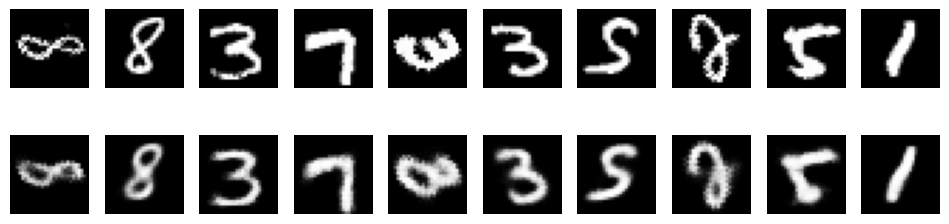

In [35]:
def show_reconstruction():

    x,_,_ = next(iter(rot_loader))

    x = x.to(device)

    with torch.no_grad():

        recon,_,_,_ = vae(x)

    fig,ax = plt.subplots(2,10,figsize=(12,3))

    for i in range(10):

        ax[0,i].imshow(x[i].cpu().squeeze(),cmap="gray")
        ax[0,i].axis("off")

        ax[1,i].imshow(recon[i].cpu().squeeze(),cmap="gray")
        ax[1,i].axis("off")

    plt.show()

show_reconstruction()

In [36]:
vae.eval()

latent_vectors=[]
labels=[]

for x,l in vae_loader:

    x = x.to(device)

    with torch.no_grad():

        mu,_ = vae.encoder(x)

    latent_vectors.append(mu.cpu())
    labels.append(l)

latent_vectors = torch.cat(latent_vectors)
labels = torch.cat(labels)

print(latent_vectors.shape)

torch.Size([60000, 8])


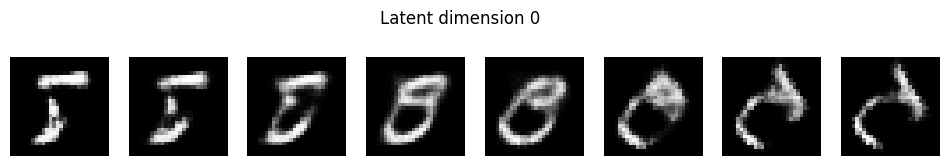

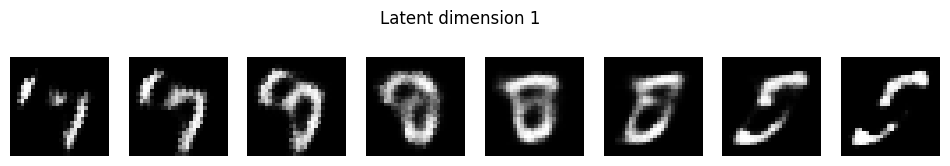

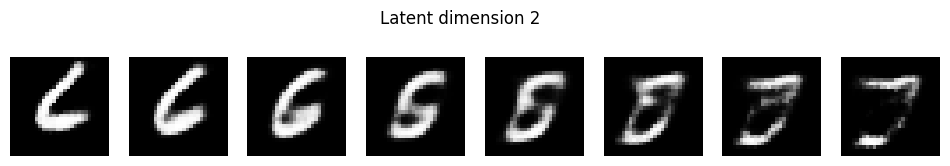

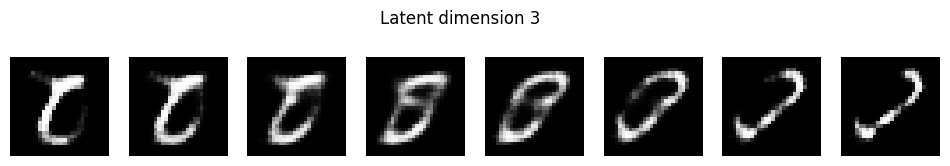

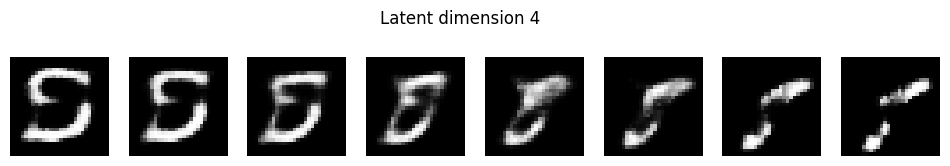

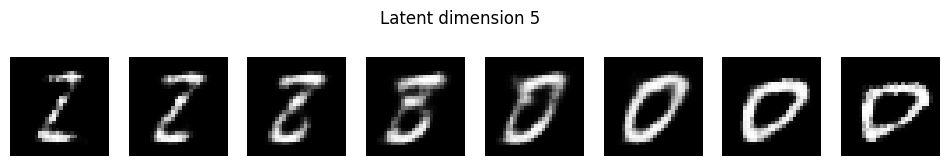

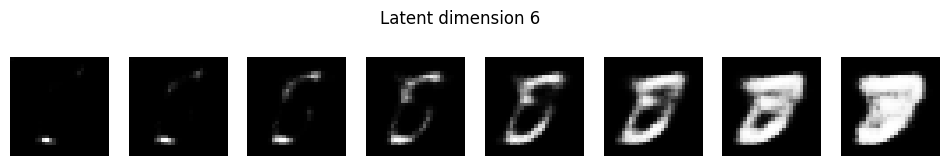

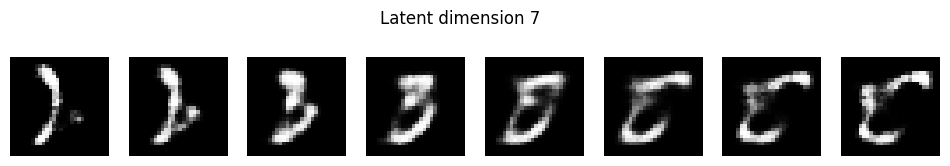

In [37]:
def latent_traversal():

    x,_,_ = rot_dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        mu,_ = vae.encoder(x)

    z = mu.squeeze()

    for dim in range(LATENT_DIM):

        fig,ax = plt.subplots(1,8,figsize=(12,2))

        for i,v in enumerate(np.linspace(-2,2,8)):

            z2 = z.clone()
            z2[dim] = v

            with torch.no_grad():
                img = vae.decoder(z2.unsqueeze(0))

            img = img.detach().cpu().squeeze().numpy()

            ax[i].imshow(img,cmap="gray")
            ax[i].axis("off")

        plt.suptitle(f"Latent dimension {dim}")
        plt.show()

latent_traversal()

In [38]:
# ============================================
# Step 0: Encode the rotated dataset to get latent vectors
# ============================================
vae.eval()  # make sure VAE is in eval mode

rot_latents = []
rot_labels = []
rot_angles = []

with torch.no_grad():
    for x, label, angle in rot_loader:
        x = x.to(device)
        mu, _ = vae.encoder(x)
        rot_latents.append(mu.cpu())
        rot_labels.append(label)
        rot_angles.append(angle)

rot_latents = torch.cat(rot_latents)
rot_labels = torch.cat(rot_labels)
rot_angles = torch.cat(rot_angles)

print("rot_latents:", rot_latents.shape)
print("rot_labels:", rot_labels.shape)
print("rot_angles:", rot_angles.shape)

rot_latents: torch.Size([324399, 8])
rot_labels: torch.Size([324399])
rot_angles: torch.Size([324399])


In [39]:
z0 = rot_latents[0]
z1 = rot_latents[1]

print("latent distance:", torch.norm(z0 - z1))

latent distance: tensor(2.0778)


In [40]:
import torch

num_pairs_per_label = 5000   # safe number

z_pairs_list = []
angle_pairs_list = []
z_targets_list = []

labels = rot_labels.unique()

for label in labels:

    idxs = (rot_labels == label).nonzero(as_tuple=True)[0]

    z_label = rot_latents[idxs]
    angles_label = rot_angles[idxs]

    n = len(idxs)

    # sample random pairs
    i_idx = torch.randint(0, n, (num_pairs_per_label,))
    j_idx = torch.randint(0, n, (num_pairs_per_label,))

    # avoid same index
    mask = i_idx != j_idx
    i_idx = i_idx[mask]
    j_idx = j_idx[mask]

    z_pairs_list.append(z_label[i_idx])
    z_targets_list.append(z_label[j_idx])

    angle_diff = angles_label[j_idx] - angles_label[i_idx]
    angle_diff = (angle_diff + 360) % 360

    angle_pairs_list.append(angle_diff)

z_pairs = torch.cat(z_pairs_list)
angle_pairs = torch.cat(angle_pairs_list)
z_targets = torch.cat(z_targets_list)

print("z_pairs:", z_pairs.shape)
print("angle_pairs:", angle_pairs.shape)
print("z_targets:", z_targets.shape)

z_pairs: torch.Size([49998, 8])
angle_pairs: torch.Size([49998])
z_targets: torch.Size([49998, 8])


In [41]:
class SupervisedTransform(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM + 2, 128),  # +2 for sin/cos
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, LATENT_DIM)
        )

    def forward(self, z, angle):

        # normalize to [0, 1]
        angle = angle.float().unsqueeze(1) / 360.0

        # convert to radians
        angle_rad = angle * 2 * torch.pi

        # circular encoding (VERY important for rotations)
        angle_feat = torch.cat([
            torch.sin(angle_rad),
            torch.cos(angle_rad)
        ], dim=1)

        # concatenate with latent
        inp = torch.cat([z, angle_feat], dim=1)

        delta = self.net(inp)

        # residual transform (no manual scaling)
        return z + delta

In [42]:
dataset_sup = torch.utils.data.TensorDataset(
    z_pairs,
    angle_pairs,
    z_targets
)

loader_sup = DataLoader(dataset_sup, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

model_sup = SupervisedTransform().to(device)

opt = torch.optim.Adam(model_sup.parameters(), lr=1e-3)

for epoch in range(30):

    total = 0

    for z, a, z_target in tqdm(loader_sup):

        z = z.to(device)
        a = a.to(device)
        z_target = z_target.to(device)

        # ------------------------
        # main supervised loss
        # ------------------------
        pred = model_sup(z, a)
        loss = F.mse_loss(pred, z_target)

        # ------------------------
        # sample second angle b
        # ------------------------
        b = torch.randint(0, 360, a.shape, device=device).float()

        # ------------------------
        # group consistency loss
        # ------------------------
        z_ab = model_sup(model_sup(z, a), b)

        z_a_plus_b = model_sup(z, (a + b) % 360)

        group_loss = F.mse_loss(z_ab, z_a_plus_b)

        # ------------------------
        # total loss
        # ------------------------
        total_loss = loss + 0.5 * group_loss

        opt.zero_grad()
        total_loss.backward()
        opt.step()

        total += total_loss.item()

    print(f"Epoch {epoch}, Loss: {total / len(loader_sup):.4f}")

100%|██████████| 391/391 [00:02<00:00, 147.74it/s]


Epoch 0, Loss: 0.2270


100%|██████████| 391/391 [00:02<00:00, 146.73it/s]


Epoch 1, Loss: 0.1721


100%|██████████| 391/391 [00:02<00:00, 151.14it/s]


...

Epoch 27, Loss: 0.1394


100%|██████████| 391/391 [00:02<00:00, 145.50it/s]


Epoch 28, Loss: 0.1392


100%|██████████| 391/391 [00:02<00:00, 149.98it/s]

Epoch 29, Loss: 0.1389


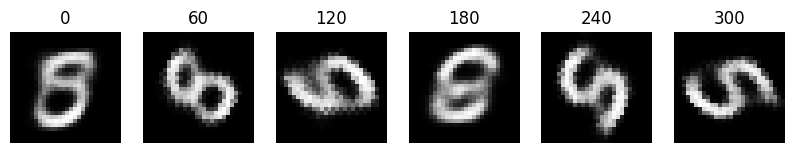

In [43]:
def visualize_supervised():

    x,_,_ = rot_dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        mu,_ = vae.encoder(x)

    fig,ax = plt.subplots(1,6,figsize=(10,2))

    for i,a in enumerate([0,60,120,180,240,300]):

        z_pred = model_sup(mu, torch.tensor([a],dtype=torch.float32, device=device).to(device))

        img = vae.decoder(z_pred).detach().cpu()

        ax[i].imshow(img.squeeze(),cmap="gray")
        ax[i].set_title(a)
        ax[i].axis("off")

    plt.show()

visualize_supervised()

In [44]:
class Oracle(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(LATENT_DIM,128),
            nn.ReLU(),

            nn.Linear(128,128),
            nn.ReLU(),

            nn.Linear(128,32),
            nn.ReLU(),

            nn.Linear(32,10)
        )

    def forward(self,z):
        return self.net(z)

In [45]:
oracle = Oracle().to(device)

opt = torch.optim.Adam(oracle.parameters(),lr=1e-3)

dataset_oracle = torch.utils.data.TensorDataset(
    rot_latents,
    rot_labels
)

loader_oracle = DataLoader(dataset_oracle, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

for epoch in range(10):

    for z,l in tqdm(loader_oracle):

        z = z.to(device)
        l = l.to(device)

        logits = oracle(z)

        loss = F.cross_entropy(logits,l)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("epoch",epoch)

100%|██████████| 2535/2535 [00:07<00:00, 324.26it/s]


epoch 0


100%|██████████| 2535/2535 [00:07<00:00, 334.16it/s]


epoch 1


100%|██████████| 2535/2535 [00:07<00:00, 335.09it/s]


...

epoch 7


100%|██████████| 2535/2535 [00:07<00:00, 327.28it/s]


epoch 8


100%|██████████| 2535/2535 [00:07<00:00, 332.77it/s]

epoch 9


In [46]:
def latent_rotate(z, theta):
    z_content = z[:, :-2]
    z_rot = z[:, -2:]

    cos_t = torch.cos(theta).unsqueeze(1)
    sin_t = torch.sin(theta).unsqueeze(1)

    x = z_rot[:, 0:1]
    y = z_rot[:, 1:2]

    x_new = cos_t * x - sin_t * y
    y_new = sin_t * x + cos_t * y

    z_rot_new = torch.cat([x_new, y_new], dim=1)

    return torch.cat([z_content, z_rot_new], dim=1)

In [47]:
# ======================================
# Unsupervised Symmetry Discovery (Corrected)
# ======================================

NUM_GENERATORS = 2
EPS = 0.15

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM,64),
            nn.ReLU(),
            nn.Linear(64,64),
            nn.ReLU(),
            nn.Linear(64,LATENT_DIM)
        )

    def forward(self,z):
        return self.net(z)

generators = nn.ModuleList([Generator().to(device) for _ in range(NUM_GENERATORS)])
optimizer = torch.optim.Adam(generators.parameters(), lr=1e-3)

In [48]:
for epoch in range(20):
    total = 0.0

    for z, l in tqdm(loader_oracle):

        z = z.to(device)

        # --------------------------
        # Apply all generators to z
        # --------------------------
        z_next = z.clone()
        for g in generators:
            z_next = z_next + EPS * g(z_next)  # sequentially apply each generator

        # --------------------------
        # Invariance loss: oracle logits should not change
        # --------------------------
        with torch.no_grad():
            logits_orig = oracle(z)
        logits_new = oracle(z_next)

        inv_loss = F.mse_loss(logits_new, logits_orig)

        # --------------------------
        # Norm preservation (rotation subspace)
        # --------------------------
        z_rot_norm = torch.norm(z[:, -2:], dim=1)
        z_next_rot_norm = torch.norm(z_next[:, -2:], dim=1)
        norm_loss = F.mse_loss(z_rot_norm, z_next_rot_norm)

        # --------------------------
        # Optional circle constraint
        # --------------------------
        circle_loss = ((z_rot_norm - 1.0)**2).mean()

        # --------------------------
        # Total loss
        # --------------------------
        loss = inv_loss + 0.1*norm_loss + 0.1*circle_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"Epoch {epoch}, loss = {total/len(loader_oracle):.4f}")

100%|██████████| 2535/2535 [00:12<00:00, 208.93it/s]


Epoch 0, loss = 0.0182


100%|██████████| 2535/2535 [00:12<00:00, 210.56it/s]


Epoch 1, loss = 0.0179


100%|██████████| 2535/2535 [00:12<00:00, 210.57it/s]


...

Epoch 17, loss = 0.0179


100%|██████████| 2535/2535 [00:12<00:00, 208.96it/s]


Epoch 18, loss = 0.0179


100%|██████████| 2535/2535 [00:12<00:00, 210.57it/s]

Epoch 19, loss = 0.0179


In [49]:
def visualize_generator(gen):

    x,_ = vae_dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        mu,_ = vae.encoder(x)

    z = mu

    fig,ax = plt.subplots(1,10,figsize=(15,2))

    for i in range(10):

        img = vae.decoder(z).detach().cpu()

        ax[i].imshow(img.squeeze(),cmap="gray")
        ax[i].axis("off")

        z = z + EPS*gen(z)

    plt.show()

Generator 0


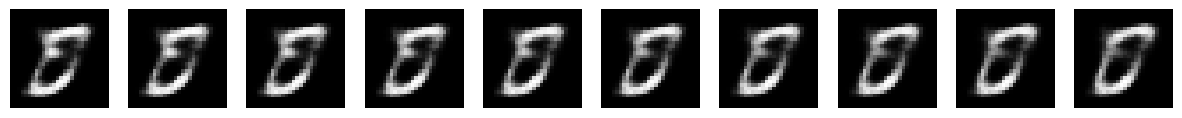

Generator 1


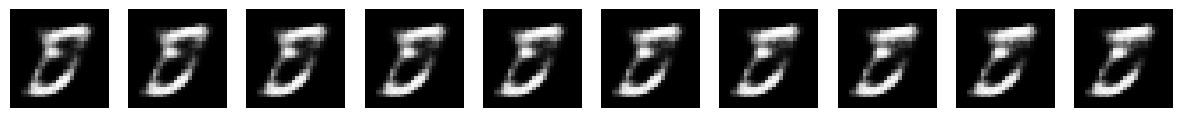

In [50]:
for i,g in enumerate(generators):

    print("Generator",i)

    visualize_generator(g)

In [51]:
class InvariantClassifier(nn.Module):

    def __init__(self, oracle):
        super().__init__()
        self.oracle = oracle

    def forward(self, z):

        preds = []

        for theta in torch.linspace(0, 2*torch.pi, steps=12, device=z.device):

            theta_batch = torch.full((z.size(0),), theta, device=z.device)

            z_rot = latent_rotate(z, theta_batch)

            preds.append(self.oracle(z_rot))

        return torch.mean(torch.stack(preds), dim=0)

In [52]:
# ======================================
# Rotated MNIST Test Dataset
# ======================================

test_dataset = RotatedMNIST(train=False)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("Test samples:", len(test_dataset))

Test samples: 54099


In [53]:
# ======================================
# Evaluate normal classifier
# ======================================

def evaluate_oracle():

    correct = 0
    total = 0

    vae.eval()
    oracle.eval()

    with torch.no_grad():

        for x,label,_ in test_loader:

            x = x.to(device)
            label = label.to(device)

            mu,_ = vae.encoder(x)

            logits = oracle(mu)

            pred = logits.argmax(dim=1)

            correct += (pred==label).sum().item()
            total += label.size(0)

    acc = correct/total

    print("Oracle accuracy:",acc)

evaluate_oracle()

Oracle accuracy: 0.9160612950331799


In [54]:
rotation_generator = generators[0]

inv_model = InvariantClassifier(oracle).to(device)

In [55]:
# ======================================
# Evaluate invariant classifier
# ======================================

def evaluate_invariant():

    correct = 0
    total = 0

    with torch.no_grad():

        for x,label,_ in test_loader:

            x = x.to(device)
            label = label.to(device)

            mu,_ = vae.encoder(x)

            logits = inv_model(mu)

            pred = logits.argmax(dim=1)

            correct += (pred==label).sum().item()
            total += label.size(0)

    acc = correct/total

    print("Invariant classifier accuracy:",acc)

evaluate_invariant()

Invariant classifier accuracy: 0.7087007153551822


In [56]:
# ======================================
# Accuracy vs Rotation
# ======================================

angles_list = list(range(0,360,30))

oracle_acc=[]
inv_acc=[]

for angle in angles_list:

    correct_oracle=0
    correct_inv=0
    total=0

    with torch.no_grad():

        for x,label,a in test_loader:

            mask = (a==angle)

            if mask.sum()==0:
                continue

            x = x[mask].to(device)
            label = label[mask].to(device)

            mu,_ = vae.encoder(x)

            logits_oracle = oracle(mu)
            logits_inv = inv_model(mu)

            pred_oracle = logits_oracle.argmax(dim=1)
            pred_inv = logits_inv.argmax(dim=1)

            correct_oracle += (pred_oracle==label).sum().item()
            correct_inv += (pred_inv==label).sum().item()

            total += label.size(0)

    if total > 0:
        oracle_acc.append(correct_oracle/total)
        inv_acc.append(correct_inv/total)
    else:
        oracle_acc.append(None)
        inv_acc.append(None)

print("Done")

Done


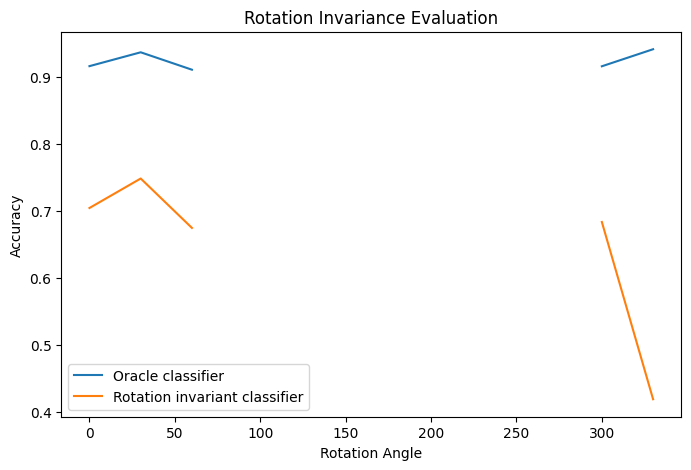

In [57]:
# ======================================
# Plot accuracy vs rotation
# ======================================

plt.figure(figsize=(8,5))

plt.plot(angles_list,oracle_acc,label="Oracle classifier")
plt.plot(angles_list,inv_acc,label="Rotation invariant classifier")

plt.xlabel("Rotation Angle")
plt.ylabel("Accuracy")

plt.title("Rotation Invariance Evaluation")

plt.legend()
plt.show()

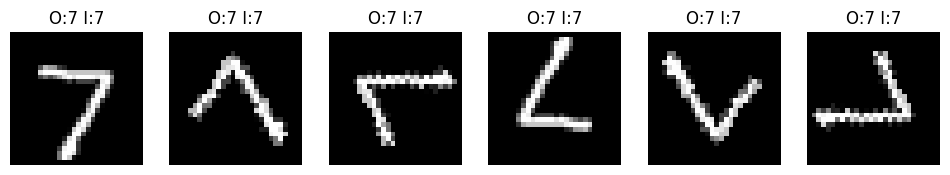

In [58]:
# ======================================
# Visual test
# ======================================

def visualize_predictions():

    x,label,angle = test_dataset[0]

    fig,ax = plt.subplots(1,6,figsize=(12,2))

    for i,a in enumerate([0,60,120,180,240,300]):

        img = rotate(x,a)

        inp = img.unsqueeze(0).to(device)

        with torch.no_grad():

            mu,_ = vae.encoder(inp)

            p1 = oracle(mu).argmax().item()
            p2 = inv_model(mu).argmax().item()

        ax[i].imshow(img.squeeze(),cmap="gray")

        ax[i].set_title(f"O:{p1} I:{p2}")
        ax[i].axis("off")

    plt.show()

visualize_predictions()

In [59]:
def random_rotation_test():

    correct=0
    total=0

    for x,label,_ in test_loader:

        angle = random.uniform(0,360)

        x_rot = torch.stack([rotate(img, angle) for img in x])

        x_rot = x_rot.to(device)
        label = label.to(device)

        with torch.no_grad():

            mu,_ = vae.encoder(x_rot)

            logits = inv_model(mu)

            pred = logits.argmax(dim=1)

        correct += (pred==label).sum().item()
        total += label.size(0)

    print("Random rotation accuracy:",correct/total)

random_rotation_test()

Random rotation accuracy: 0.564594539640289


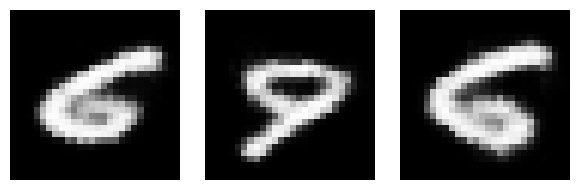

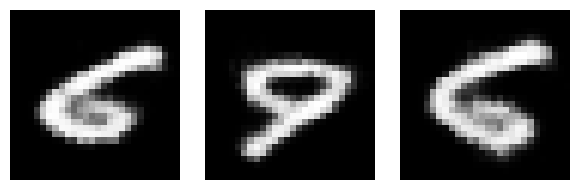

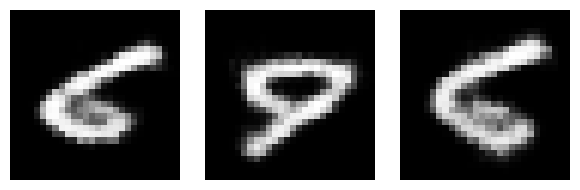

In [60]:
import matplotlib.pyplot as plt

def show(img):

    img = img.detach().cpu()

    batch = img.shape[0]

    fig, axs = plt.subplots(1, batch, figsize=(batch*2,2))

    if batch == 1:
        axs = [axs]

    for i in range(batch):
        axs[i].imshow(img[i].squeeze(), cmap="gray")
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()

z = mu

for i in range(3):

    img = vae.decoder(z)
    show(img)

    theta = torch.tensor([0.2], device=device)
    z = latent_rotate(z, theta)

In [61]:
z = rot_latents[0].to(device).unsqueeze(0)

for angle in [0,30,60,90,120]:

    z_pred = model_sup(z, torch.tensor([angle], dtype=torch.float32, device=device).to(device))

    print(torch.norm(z_pred - z))

tensor(0.9313, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(1.9050, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(2.7455, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(2.4964, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(2.3644, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)


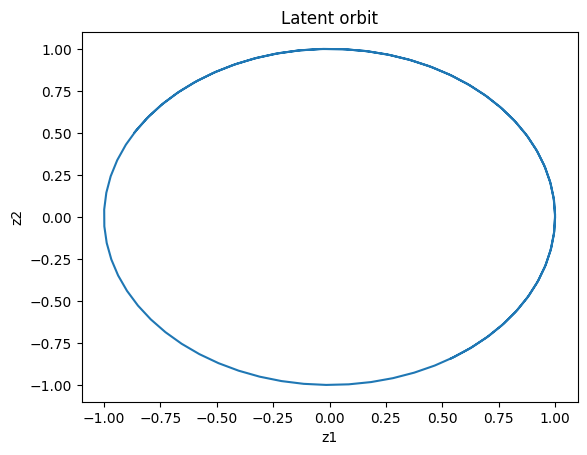

In [62]:
trajectory = []

z = rot_latents[0].to(device).unsqueeze(0)

for i in range(100):
    z_rot = z[:, -2:]
    z_rot = z_rot / (z_rot.norm(dim=1, keepdim=True) + 1e-8)

    trajectory.append(z_rot.cpu().numpy().squeeze())

    theta = torch.tensor([0.1], device=device)
    z = latent_rotate(z, theta)

trajectory = np.array(trajectory)

plt.plot(trajectory[:,0], trajectory[:,1])
plt.title("Latent orbit")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

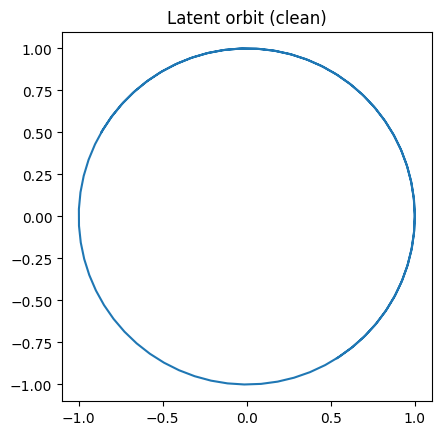

In [63]:
plt.plot(trajectory[:,0], trajectory[:,1])
plt.gca().set_aspect('equal')  # 🔥 important
plt.title("Latent orbit (clean)")
plt.show()

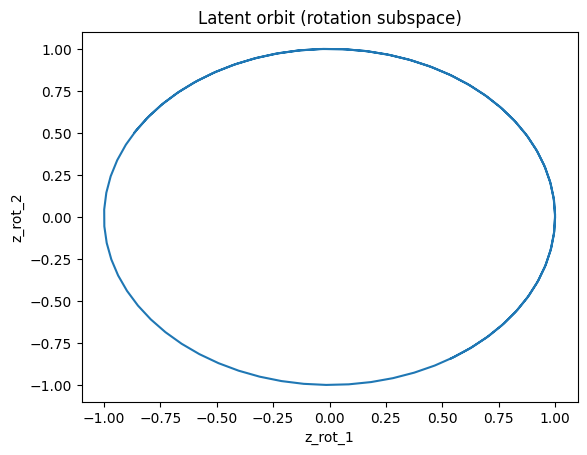

In [64]:
plt.plot(trajectory[:,-2], trajectory[:,-1])
plt.title("Latent orbit (rotation subspace)")
plt.xlabel("z_rot_1")
plt.ylabel("z_rot_2")
plt.show()

In [65]:
print(np.std(trajectory[:,0]), np.std(trajectory[:,1]))   # should be ~0
print(np.std(trajectory[:,-2]), np.std(trajectory[:,-1])) # should be >0

0.6953123 0.69262445
0.6953123 0.69262445
